In [1]:
import sys
import os
import numpy as np

gmat_path = os.environ["GMAT_PATH"]
assert gmat_path, "Please set the GMAT_PATH environment variable"

startup = os.path.join(gmat_path, "bin", "api_startup_file.txt")
assert os.path.exists(startup), "Cannot find " + startup

sys.path.insert(1, os.path.join(gmat_path, "bin"))
import gmatpy as gmat

gmat.Setup(startup)

In [2]:
kwargs = {}

coe_mi = np.array([6.54140000e03, 6.00000000e-01, 1.06256103e00, 1.48178453e00, 2.03829905e00, -2.00748699e-17])
earth_grav_path = os.path.join(gmat_path, "data", "gravity", "earth", "JGM3.cof")
moon_grav_path = os.path.join(gmat_path, "data", "gravity", "luna", "grgm900c.cof")

moon_ci = gmat.Construct("CoordinateSystem", "MOON_CI", "Luna", "ICRF")

# Spacecraft
sc = gmat.Construct("Spacecraft", "LunaOrbiter")
sc.SetField("DateFormat", "UTCGregorian")
sc.SetField("Epoch", "1 Jan 2020 12:00:00.000")
sc.SetField("CoordinateSystem", "MOON_CI")
# sc.SetField("DisplayStateType", "Keplerian")

# Orbital state
sc.SetField("SMA", coe_mi[0])
sc.SetField("ECC", coe_mi[1])
sc.SetField("INC", np.rad2deg(coe_mi[2]))
sc.SetField("RAAN", np.rad2deg(coe_mi[3]))
sc.SetField("AOP", np.rad2deg(coe_mi[4]))
sc.SetField("TA", np.rad2deg(coe_mi[5]))

# Spacecraft ballistic properties for the SRP and Drag models
if "SRPArea" in kwargs:
    sc.SetField("SRPArea", 2.5)
if "Cr" in kwargs:
    sc.SetField("Cr", 1.75)
if "DragArea" in kwargs:
    sc.SetField("DragArea", 1.8)
if "Cd" in kwargs:
    sc.SetField("Cd", 2.1)

sc.SetField("DryMass", 80)

# Force model
grav = gmat.Construct("GravityField")
grav.SetField("BodyName", "Luna")
grav.SetField("PotentialFile", moon_grav_path)
grav.SetField("Degree", 20)
grav.SetField("Order", 20)

fm = gmat.Construct("ForceModel", "FM")
fm.SetField("CentralBody", "Luna")
fm.AddForce(grav)
fm.SetField("PointMasses", ["Earth", "Sun"])

gmat.Initialize()

In [27]:
gator = gmat.Construct("RungeKutta4", "Gator")
pdprop = gmat.Construct("Propagator","PDProp")
pdprop.SetReference(gator)
pdprop.SetReference(fm)
pdprop.SetField("MinStep", 10.0)
pdprop.SetField("MaxStep", 10.0)

gmat.Initialize()

pdprop.AddPropObject(sc)
pdprop.PrepareInternals()
gator = pdprop.GetPropagator()

Dt = 10.0
tf = 31 * 24 * 3600.0
N_steps = int(tf / Dt)
tfs = np.linspace(0, tf, N_steps)
print(N_steps)

267840


In [28]:
rv = np.zeros((N_steps, 6))
step_sizes = np.zeros(N_steps)
for i in range(N_steps):
   gator.Step(Dt)
   rv[i] = gator.GetState()

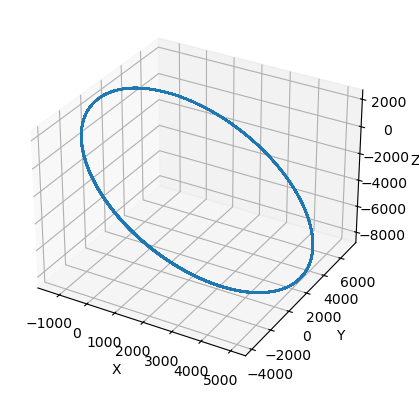

In [6]:
import matplotlib.pyplot as plt
# 3d plot
fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
ax.plot(rv[:,0], rv[:,1], rv[:,2])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()